In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

train_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20_norm,sensor_21_norm,sensor_11_rolling_mean,sensor_14_rolling_mean,sensor_4_rolling_mean,sensor_17_rolling_mean,sensor_11_delta,sensor_14_delta,sensor_4_delta,sensor_17_delta
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,-0.024002,-0.079912,41.6900,8074.830000,1112.930000,330.0,0.00,0.00,0.00,0.0
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,-0.940905,-0.634450,42.8150,8060.480000,1175.215000,345.5,2.25,-28.70,124.57,31.0
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,-1.204026,0.681673,42.4300,8062.526667,1155.826667,340.0,-2.28,20.49,-120.45,-32.0
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,-0.698302,0.629779,42.2425,8065.907500,1146.377500,337.0,0.02,9.43,0.98,-1.0
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,-2.185794,1.153795,41.0900,8025.886000,1123.820000,330.6,-5.20,-210.25,-84.44,-23.0


In [3]:
RUL_CAP = 125

train_df["RUL_capped"] = (
    train_df["RUL"]
    .clip(upper=RUL_CAP)
)

In [13]:
DROP_COLS = [
    "unit_number",
    "RUL",
    "RUL_capped",
    "max_cycle",
    "life_fraction"
]
features = [
    col
    for col in train_df.columns
    if col not in DROP_COLS
]

X = train_df[features]

y = train_df["RUL_capped"]

In [14]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(
        X,
        y,
        groups=train_df["unit_number"]
    )
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [15]:
print(X_train.shape)
print(X_val.shape)

(49294, 50)
(11955, 50)


In [16]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
preds = model.predict(
    X_val
)

In [18]:
mae = mean_absolute_error(
    y_val,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        preds
    )
)

r2 = r2_score(
    y_val,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 12.705779075622559
RMSE: 19.38295971200646
R²  : 0.7751469612121582


In [19]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(20)

,feature,importance
33,sensor_11_norm,0.519564
36,sensor_14_norm,0.094400
32,sensor_9_norm,0.069264
22,engine_age,0.038048
27,sensor_4_norm,0.035738
35,sensor_13_norm,0.024790
29,sensor_6_norm,0.024381
0,time_cycle,0.021075
31,sensor_8_norm,0.017263
37,sensor_17_norm,0.013758


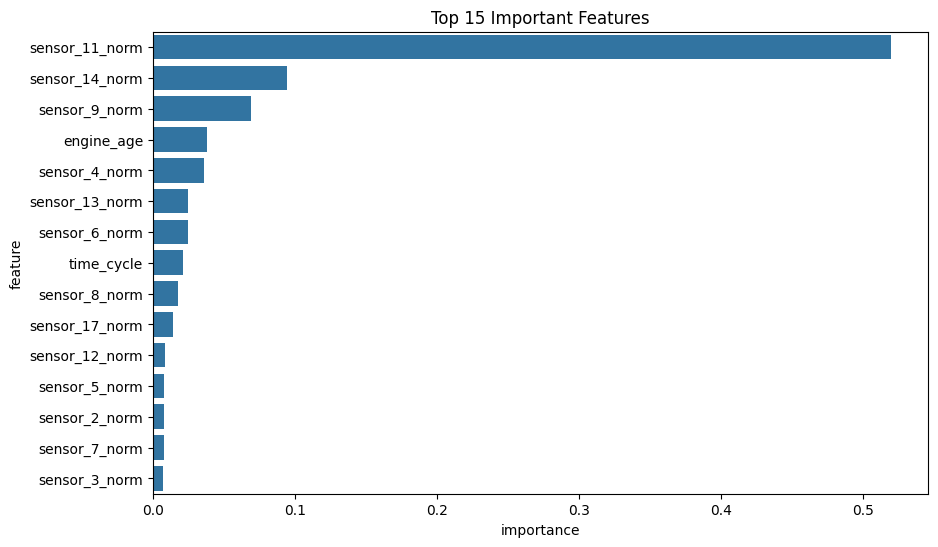

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [21]:
importance.head(15)

,feature,importance
33,sensor_11_norm,0.519564
36,sensor_14_norm,0.094400
32,sensor_9_norm,0.069264
22,engine_age,0.038048
27,sensor_4_norm,0.035738
35,sensor_13_norm,0.024790
29,sensor_6_norm,0.024381
0,time_cycle,0.021075
31,sensor_8_norm,0.017263
37,sensor_17_norm,0.013758
